# Regresión Lineal con Redes Neuronales
**Dataset:** Industria Florícola - Precio de Exportación vs Diámetro de Rosas Amarillas

En este notebook aplicaré una red neuronal para resolver un problema real del sector agroindustrial y de exportación. El objetivo es predecir el **Precio de Exportación (en USD por caja)** de rosas amarillas categoría Premium, Utilizando como atributo matemático principal el **Diámetro Promedio que tiene una Flor (en cm)**. 

En el mercado internacional, el volumen y apertura de los pétalos (el tamaño del botón de una flor) es un indicador directo de la calidad y este es el que define el precio.

Durante el ejercicio voy a mostrar cómo se comporta la red neuronal en tres situaciones: cuando aprende bien el patrón de los datos, cuando no logra aprenderlo (subentrenamiento), y cuando lo aprende demasiado al pie de la letra y pierde capacidad de predicción (sobreentrenamiento).

1 - Preparación de los datos

In [13]:
## 1.1 - Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras

# Semilla para que los cálculos sean reproducibles
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
## 1.2 - Generación de datos sintéticos
# Simulamos el registro de una finca exportadora de rosas amarillas
n_muestras = 150
X = np.random.uniform(4.5, 7.5, n_muestras).reshape(-1, 1)

# Cada centímetro extra de diámetro aumenta el valor comercial,
# más un ruido aleatorio que simula fluctuaciones del mercado internacional
y = 18.5 * X + np.random.normal(0, 4.5, (n_muestras, 1)) - 25

print("Forma de X (Diámetro en cm):", X.shape)
print("Forma de y (Precio en USD):", y.shape)
print("\nPrimeros 5 diámetros (cm):", X[:5].flatten())
print("\nPrimeros 5 precios (USD):", y[:5].flatten())

Forma de X (Diámetro en cm): (150, 1)
Forma de y (Precio en USD): (150, 1)

Primeros 5 diámetros (cm): [5.62362036 7.35214292 6.69598183 6.29597545 4.96805592]

Primeros 5 precios (USD): [ 78.17135225 112.37160705  98.71946081  86.2164947   72.05173721]


El dataset que estamos usando tiene 150 registros sintéticos con 1 característica de entrada. El precio se está expresado en dólares por caja.

Las variables son:

X - Es el diámetro de la flor: el valor ronda entre 4.5 cm y 7.5 cm

y - Es el precio de exportación: precio en USD por caja, esta calculado en base al diámetro más la variación de mercado

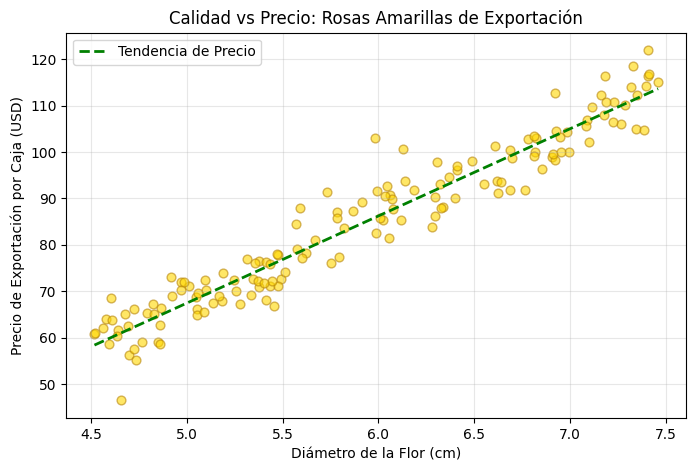

La línea verde confirma la tendencia: a mayor diámetro de la flor, mayor es el precio en el mercado internacional.


In [15]:
## 1.3 - Visualización de la tendencia comercial
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, color='gold', edgecolor='darkgoldenrod', s=40)

# Línea de tendencia comercial (valoración ideal)
m, b = np.polyfit(X.flatten(), y.flatten(), 1)
x_linea = np.linspace(X.min(), X.max(), 100)
plt.plot(x_linea, m * x_linea + b, color='green', linewidth=2,
         linestyle='--', label='Tendencia de Precio')

plt.xlabel('Diámetro de la Flor (cm)')
plt.ylabel('Precio de Exportación por Caja (USD)')
plt.title('Calidad vs Precio: Rosas Amarillas de Exportación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("La línea verde confirma la tendencia: a mayor diámetro de la flor, mayor es el precio en el mercado internacional.")

In [16]:
## 1.4 - División y normalización de los datos
# Separamos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizamos para que la red neuronal aprenda de una forma más eficiente
# Esto lleva todos los valores a media 0 y desviación estándar 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (120, 1)
Datos de prueba: (30, 1)


2 - Modelo bien entrenado

Un modelo bien entrenado va a aprender la tendencia general sin memorizar los datos. En nuestro caso, la red debe entender que a mayor diámetro de la flor, mayor es el precio, sin obsesionarse con cada variación puntual del mercado.
Aqui usaremos una función para construir el modelo y así reutilizarla en los 3 experimentos, lo único que cambiará entre ellos es la cantidad de épocas.

2.1 - Construcción del modelo

Aquí definimos la arquitectura de la red neuronal dentro de una función reutilizable. Usaremos tres capas ocultas con activación ReLU y una capa de salida sin activación porque estamos prediciendo un valor numérico continuo, no clasificando.

In [30]:
# Definimos la función que construye el modelo, la usaremos en los 3 experimentos
def crear_modelo():
    modelo = keras.Sequential([
        # Capa 1: recibe el diámetro y detecta patrones básicos
        keras.layers.Dense(64, activation='relu', input_shape=(1,)),
        # Capa 2: refina los patrones encontrados
        keras.layers.Dense(32, activation='relu'),
        # Capa 3: ajuste fino antes de la salida
        keras.layers.Dense(16, activation='relu'),
        # Salida: devuelve el precio estimado en USD
        keras.layers.Dense(1)
    ])
    # Adam como optimizador y MSE como función de pérdida para regresión
    modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return modelo

# Creamos una instancia para ver la estructura del modelo
modelo_prueba = crear_modelo()
modelo_prueba.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

2.2 - Entrenamiento

Aquí vamos a entrenar el modelo con 100 épocas, es lo suficiente para aprender la relación entre diámetro y precio sin memorizar las fluctuaciones del mercado.

In [31]:
# Creamos una instancia limpia del modelo usando la función definida
modelo_bueno = crear_modelo()

# Entrenamos el modelo con los datos de entrenamiento
historia_bueno = modelo_bueno.fit(
    X_train, y_train,
    epochs=100,                        # 100 ciclos de entrenamiento
    batch_size=32,                     # Procesa 32 muestras por paso
    validation_data=(X_test, y_test),  # Validamos con datos que el modelo no ha visto
    verbose=0                          # Ocultamos el log para no llenar la pantalla
)

print("Entrenamiento completado.")

Entrenamiento completado.


2.3 - Evaluación del modelo

En este apartado medimos qué tan precisas son las predicciones del modelo usando los datos de prueba que nunca vio durante el entrenamiento.

In [32]:
# Generamos las predicciones con los datos de prueba
predicciones_bueno = modelo_bueno.predict(X_test).flatten()

# Calculamos el error promedio y el coeficiente de determinación
mse_bueno = mean_squared_error(y_test, predicciones_bueno)  # Error en la predicción del precio
r2_bueno = r2_score(y_test, predicciones_bueno)             # Qué tanto explica la variación del precio

print(f"MSE: {mse_bueno:.4f}")
print(f"R2:  {r2_bueno:.4f}")
print(f"\nEl modelo explica el {r2_bueno*100:.1f}% de la variabilidad del precio de exportación")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
MSE: 48.5846
R2:  0.8343

El modelo explica el 83.4% de la variabilidad del precio de exportación


2.4 - Visualización de resultados

Aquí se grafica las curvas de aprendizaje y la comparación entre los precios reales y predichos. EN el caso de que el modelo aprendió bien, ambas curvas deben bajar juntas y los puntos deben alinearse cerca de la línea verde.

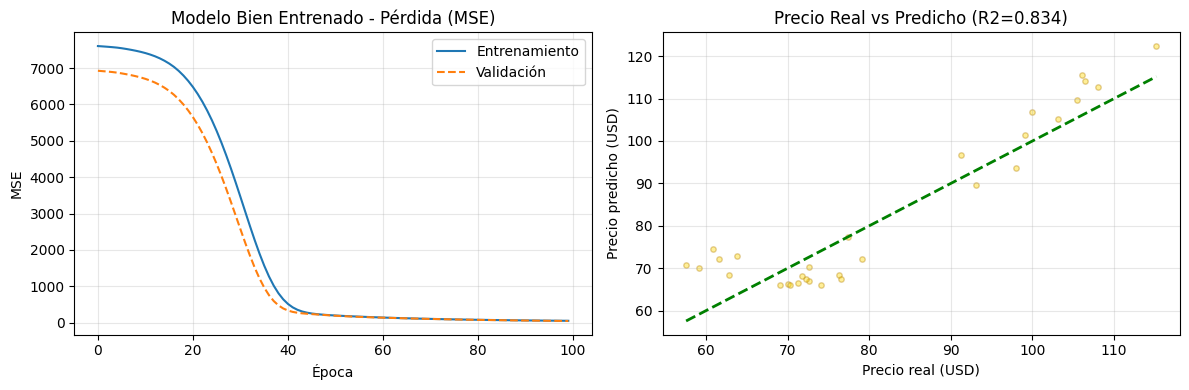

Las curvas bajan juntas y se estabilizan: el modelo aprendió la tendencia comercial sin memorizar el ruido del mercado.


In [33]:
plt.figure(figsize=(12, 4))

# Gráfica 1: curvas de pérdida durante el entrenamiento y validación
plt.subplot(1, 2, 1)
plt.plot(historia_bueno.history['loss'], label='Entrenamiento')
plt.plot(historia_bueno.history['val_loss'], label='Validación', linestyle='--')
plt.title('Modelo Bien Entrenado - Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica 2: precio real vs precio predicho por el modelo
plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_bueno, alpha=0.4, s=15, color='gold', edgecolor='darkgoldenrod')
# Línea verde: representa la predicción perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.title(f'Precio Real vs Predicho (R2={r2_bueno:.3f})')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Las curvas bajan juntas y se estabilizan: el modelo aprendió la tendencia comercial sin memorizar el ruido del mercado.")